# Homework 5: Hypothesis Testing and Monte Carlo

BEE 4850/5850, Spring 2025

**Name**:

**ID**:

> **Due Date**
>
> Friday, 4/17/26, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practicing approaches to
extreme value analysis and using information criteria to assess evidence
for models.

-   Problem 1 asks you to conduct a null hypothesis test using model
    simulations.
-   Problem 1 asks you to use $p$-values to compare two data-generating
    hypotheses.
-   Problem 3 asks you to use Monte Carlo optimization to identify
    bidding strategies for The Showcase from The Price is Right.
-   Problem 4 asks you to use Monte Carlo optimization to identify house
    elevation strategies to mitigate flooding damages.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [1]:
using Random # random number generation and seed-setting
using DataFrames # tabular data structure
using DataFramesMeta # API which can simplify chains of DataFrames transformations
using CSV # reads/writes .csv files
using Distributions # interface to work with probability distributions
using Plots # plotting library
using StatsBase # statistical quantities like mean, median, etc
using StatsPlots # some additional statistical plotting tools
using Dates

## Problems

### Scoring

-   Problem 1 is worth 3 points;
-   Problem 2 is worth 5 points;
-   Problem 3 is worth 7 points;
-   Problem 4 is worth 10 points.

### Problem 1 (3 points)

Revisit [Problem 1 from Homework
1](https://envdata.viveks.me/spring2026/hw/hw01/hw01.html#problem-1-7-points).

> The underlying question we would like to address is: what is the
> influence of drinking beer on the likelihood of being bitten by
> mosquitoes? There is a mechanistic reason why this might occur:
> mosquitoes are attracted by changes in body temperature and released
> CO<sub>2</sub>, and it might be that drinking beer induces these
> changes. We’ll analyze this question using (synthetic) data which
> separates an experimental population into two groups, one which drank
> beer and the other which drank only water.

Now we would like to **test** the null hypothesis that drinking beer
makes no difference in attracting mosquitoes. Repeat the analysis from
HW1. What is the $p$-value of the observed data under this null
hypothesis? If you are interested in testing statistical significance of
the proposed alternative hypothesis that beer attracts mosquitoes at the
95% confidence level, what could you conclude that this effect? In other
words:

-   is the alternative hypothesis statistically significant at this
    confidence level?
-   is the observation more consistent with the alternative hypothesis
    than the null hypothesis?
-   what does your finding imply about any conclusions you might draw
    about this proposed effect?

### Problem 2 (5 points)

Revisit [Problem 5 from Homework
1](https://envdata.viveks.me/spring2026/hw/hw01/hw01.html#problem-5-5-points).

> You are trying to detect how prevalent cheating was on an exam. You
> are skeptical of the efficacy of just asking the students if they
> cheated. You are also concerned about privacy — your goal is not to
> punish individual students, but to see if there are systemic problems
> that need to be addressed. Someone proposes the following interview
> procedure, which the class agrees to participate in:

> Each student flips a fair coin, with the results hidden from the
> interviewer. The student answers honestly if the coin comes up heads.
> Otherwise, if the coin comes up tails, the student flips the coin
> again, and answers “I did cheat” if heads, and “I did not cheat”, if
> tails.

> You have a hypothesis that cheating was not prevalent, and the
> proportion of cheaters was no more than 5% of the class; in other
> words, we expect 5 “true” cheaters out of a class of 100 students. Our
> TA is more jaded and thinks that cheating was more rampant, and that
> 30% of the class cheated. The proposed interview procedure is noisy:
> the interviewer does not know if an admission means that the student
> cheated, or the result of a heads. However, it gives us a
> data-generating process that we can model and analyze for consistency
> with our hypothesis and that of the TA.

Repeat this analysis and suppose that your procedure turned up 40 “yes”
answers. What is the $p$-value of having seen this data under both
hypotheses? If you wanted to draw a conclusion at a 95% confidence
level, what could you conclude about the level of cheating in the class?

### Problem 3 (7 points)

[The
Showcase](https://en.wikipedia.org/wiki/The_Price_Is_Right#Showcase) is
the final round of every episode of [The Price is
Right](https://en.wikipedia.org/wiki/The_Price_Is_Right), matching the
two big winners from the episode. Each contestant is shown a “showcase”
of prizes, which are usually some combination of a trip, a motor
vehicle, some furniture, and maybe some other stuff. They then each have
to make a bid on the retail price of the showcase. The rules are:

-   an overbid is an automatic loss;
-   the contest who gets closest to the retail price wins their
    showcase;
-   if a contestant gets within \$250 of the retail price and is closer
    than their opponent, they win both showcases.

You have been selected to appear on the show. As preparation, you have
documented historical prizes and their values. Once you’re shown the
showcase, you realize that the distribution of values for this spread of
prizes has historically followed a truncated normal distribution with
mean \$31,000 and standard deviation \$4,500, truncated between \$15,000
and \$42,000.

You can make the following assumptions about the probability of winning
and payouts:

-   If you bet the exact amount, you win with probability 1 and win both
    showcases; the value is the double of the single showcase value.
-   If you did not win both showcases but bid under the showcase value,
    the probability of being outbid increases linearly as the distance
    between your bid and the value increases (in other words, if you bid
    the exact value, you win with probability 1, and if you bid \$0, you
    win with probability 0).
-   If you overbid, you automatically lose, with value \$0.

#### Problem 3.1

Using Monte Carlo simulation, find the wager that maximizes your
probability of winning. You will need to write a function which computes
the winning probability for a given bet, then optimize that function.
Make sure to justify the sample size that you use in your Monte Carlo
analysis.

#### Problem 3.2

Using Monte Carlo simulation, find the wager that maximizes your
expected winnings. Is this the same as in Problem 3.1? Why do you think
it is or is not? Make sure to justify the sample size that you use in
your Monte Carlo analysis.

### Problem 4

You have been asked by a client to assess the risks of flooding to their
home (which is valued at \$400,000 and only floods when the stream water
levels exceed 1.5m). They would like to know whether it would be
cost-effective to elevate their home to reduce flood risks. After some
hydrologic analysis, you have developed a 40-year record of annual
maximum water levels (in m) at the nearby stream.

You also have a depth-damage function for the fraction of the home’s
value which is damaged at varying flood depths:

$$d(h) = \mathbb{I}[h > 0] \frac{1}{1+\exp(-k(x-x_0))},$$

where $k=1.25$ and $x_0=2$[1]. The graph of this function is given in
the figure below.

[1] As a reminder, the indicator function $\mathbb{I}[h > 0]$ is $0$
when the condition is not satisfied (in this case, when $h=0$) and $1$
when it is satisfied.


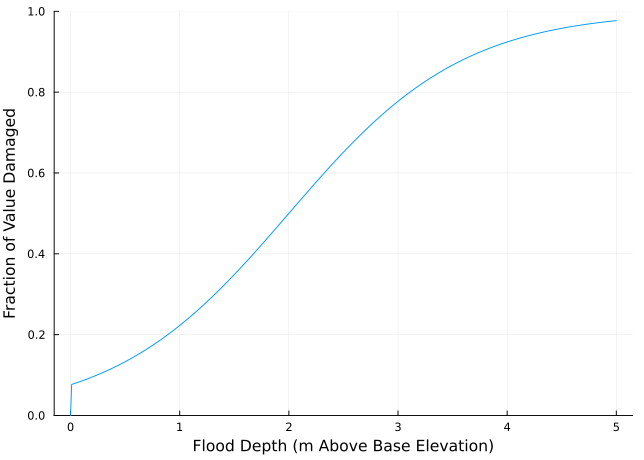

In this problem, you will need to calculate the **net present value
(NPV)** of flooding damages, which converts damages over time to a
present value using a discount rate[1] For example, if your discount
rate is 4%, a dollar next year is worth the equivalent of about 96 cents
today. More generally, with a discount rate of $\gamma$ (as a decimal),
a dollar of benefits in $t$ years is worth $\$(1-\gamma)^t$ today.

The NPV of a sequence of money $x_t$ with discount rate $\gamma$ is the
sum of all of the discounted values, that is,

$$NPV = \sum_{t=0}^T x_t (1-\gamma)^t,$$

where $T$ is the time horizon. We’ll use a discount rate of 4% in this
problem, which is typical for this type of problem, and a design horizon
of 30 years.

For this problem, we will assume that the cost of elevating the house
$\Delta h$ m is
$C(\Delta h) = \mathbb{I}[h > 0](100,000 + 2,000\Delta h)$.

#### Problem 4.1

Fit a GEV distribution to the data in `water_depths.csv`. Plot a
histogram of the data and the fitted distribution. How well does this
distribution fit the data?

#### Problem 4.2

Use Monte Carlo simulation to estimate the NPV of the benefits of
elevation levels between 0 and 5m (you don’t have to consider increments
finer than 0.5m). What elevation heights pass a cost-benefit test
(*e.g.* the net benefits of elevation (benefits of avoiding flooding
minus cost of elevation) are greater than 0)? You can assume that the
costs of elevation are all up front (that is, in year 0). What height
(including a possible elevation of 0m) maximizes the NPV of net
benefits?

[1] Discount rates reduce future monetary values to reflect the
time-value of money; that is, you would rather have a bit less money
today than none today and more next year, as you could save or invest
that money. The actual choice of discount rates is the subject of much
economic theory and plays an important role in environmental
decision-making, particularly for multi-generational investments such as
climate mitigation. For example, with a relatively large discount rate
(such as 7%), all costs and benefits after a decade are effectively
zero, which means it never appears cost-effective to e.g. reduce fossil
fuel emissions.